# Complete Probe Training Pipeline
**Unified notebook for Semantic Energy & Entropy probe training across any LLM and dataset.**

This notebook aggregates the full pipeline:
- **Phase 0**: Pre-flight verification (formulas, orientations)
- **Phase 1**: Dataset generation (multi-sample generation, hidden state extraction)
- **Phase 2**: Probe training (layer sweeps, ablation, binarization)
- **Phase 3**: Comprehensive evaluation (AUROC, AUPR, FPR@95, bootstrap CIs)
- **Phase 4**: Sentence-level baseline demo (B1 logit confidence)

> **How to use**: Change the configuration cell below to switch LLM model and dataset.
> All file paths, plot titles, and probe bundles automatically adapt.

## ⚙️ Configuration
Change these values to switch model/dataset. Everything else adapts automatically.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Change these to switch model / dataset
# ══════════════════════════════════════════════════════════════════════════════

MODEL_ID        = "Qwen/Qwen3-8B"           # HuggingFace model ID
DATASET_NAME    = "trivia_qa"               # HuggingFace dataset name
DATASET_CONFIG  = "rc"                      # Dataset config (rc = Reading Comprehension)
DATASET_SPLIT   = "validation"              # Which split to use
NUM_QUESTIONS   = 500                       # Total questions to process
NUM_SAMPLES     = 5                         # Diverse responses per question
CHECKPOINT_EVERY = 100                      # Save checkpoint every N questions
USE_8BIT        = True                      # 8-bit quantization (recommended for 12GB VRAM)

# ── Derived names (auto-generated, do not edit) ──────────────────────────────
import re
MODEL_SHORT = re.sub(r'[^a-z0-9]', '-', MODEL_ID.split('/')[-1].lower()).strip('-')
DATASET_SHORT = DATASET_NAME.replace('_', '')
DATASET_FILE = f"probe_dataset_{MODEL_SHORT}_{DATASET_SHORT}.pkl"
PROBE_FILE   = f"probes_{MODEL_SHORT}_{DATASET_SHORT}.pkl"
MODEL_LABEL  = MODEL_ID.split('/')[-1]  # For plot titles

print(f"Model:         {MODEL_ID}")
print(f"Model short:   {MODEL_SHORT}")
print(f"Dataset:       {DATASET_NAME} ({DATASET_CONFIG}/{DATASET_SPLIT})")
print(f"Questions:     {NUM_QUESTIONS} x {NUM_SAMPLES} samples")
print(f"Dataset file:  {DATASET_FILE}")
print(f"Probe file:    {PROBE_FILE}")

Model:         Qwen/Qwen3-8B
Model short:   qwen3-8b
Dataset:       trivia_qa (rc/validation)
Questions:     500 x 5 samples
Dataset file:  probe_dataset_qwen3-8b_triviaqa.pkl
Probe file:    probes_qwen3-8b_triviaqa.pkl


## Phase 0 — Setup & Pre-Flight Verification

### 0.1 — Imports and Paths

In [2]:
import sys, os, re, math, pickle, glob, time, warnings
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

REPO_ROOT    = os.path.abspath(os.path.join(os.getcwd(), '..'))
BACKEND_PATH = os.path.join(REPO_ROOT, 'backend')
DATA_DIR     = os.path.join(REPO_ROOT, 'backend', 'data')
MODELS_DIR   = os.path.join(REPO_ROOT, 'backend', 'models')
FIGS_DIR     = os.path.join(REPO_ROOT, 'notebooks', 'figures')
for d in [DATA_DIR, MODELS_DIR, FIGS_DIR]:
    os.makedirs(d, exist_ok=True)
if BACKEND_PATH not in sys.path:
    sys.path.insert(0, BACKEND_PATH)

np.random.seed(42)
print(f"Repo root : {REPO_ROOT}")
print(f"Data dir  : {DATA_DIR}")
print(f"Models dir: {MODELS_DIR}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Repo root : d:\Github Repositories\SemanticEnergy
Data dir  : d:\Github Repositories\SemanticEnergy\backend\data
Models dir: d:\Github Repositories\SemanticEnergy\backend\models
CUDA: True
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.0 GB


### 0.2 — Verify Energy Teacher Formula
Path: `cal_flow -> sum_normalize -> cluster_energies[main_cluster_idx]`

In [3]:
from engine import cal_flow, sum_normalize, cal_cluster_ce, cal_probs, cal_boltzmann_logits

probs_list_example = [[0.9, 0.85, 0.88], [0.87, 0.82, 0.91], [0.4, 0.35, 0.3]]
logits_list_example = [[5.2, 4.8, 5.0], [4.9, 4.7, 5.1], [1.2, 0.9, 0.7]]
clusters_example = [[0, 1], [2]]

probs_se, logits_se = cal_flow(probs_list_example, logits_list_example, clusters_example, fermi_mu=None)
cluster_energies = sum_normalize(logits_se)
main_cluster_idx = next(idx for idx, c in enumerate(clusters_example) if 0 in c)
main_confidence = cluster_energies[main_cluster_idx]

print(f"cluster_energies: {cluster_energies}")
print(f"Sum: {sum(cluster_energies):.6f}  (should be 1.0)")
print(f"main_confidence: {main_confidence:.4f}")
assert 0.0 <= main_confidence <= 1.0
assert abs(sum(cluster_energies) - 1.0) < 1e-9
print("PASS: energy_score_raw verified")

cluster_energies: [0.9138461538461539, 0.08615384615384615]
Sum: 1.000000  (should be 1.0)
main_confidence: 0.9138
PASS: energy_score_raw verified


### 0.3 — Verify Entropy Teacher Formula

In [4]:
def cluster_assignment_entropy(clusters):
    sizes = [len(c) for c in clusters]
    n = sum(sizes)
    probs = [s / n for s in sizes]
    return -sum(p * math.log(p + 1e-10) for p in probs)

e1 = cluster_assignment_entropy([[0, 1, 2, 3, 4]])
e2 = cluster_assignment_entropy([[0], [1], [2], [3], [4]])
print(f"All one cluster: {e1:.8f} (should be ~0)")
print(f"5 singletons:    {e2:.6f} (max ~ {math.log(5):.4f})")
assert e1 >= -1e-8 and e2 >= e1
print("PASS: Entropy formula verified")

All one cluster: -0.00000000 (should be ~0)
5 singletons:    1.609438 (max ~ 1.6094)
PASS: Entropy formula verified


### 0.4 — Score Orientation Verification

In [5]:
np.random.seed(42)
N = 200
correctness_synth = np.random.binomial(1, 0.6, N).astype(float)
energy_synth = correctness_synth * np.random.uniform(0.6, 0.95, N) + (1 - correctness_synth) * np.random.uniform(0.1, 0.5, N)
entropy_synth = (1 - correctness_synth) * np.random.uniform(1.0, 1.6, N) + correctness_synth * np.random.uniform(0.0, 0.5, N)
rho_e, _ = spearmanr(energy_synth, correctness_synth)
rho_h, _ = spearmanr(entropy_synth, correctness_synth)
print(f"Energy  rho: {rho_e:+.3f} [expected: positive]")
print(f"Entropy rho: {rho_h:+.3f} [expected: negative]")
assert rho_e > 0 and rho_h < 0
print("PASS: Both orientations correct")

Energy  rho: +0.845 [expected: positive]
Entropy rho: -0.845 [expected: negative]
PASS: Both orientations correct


## Phase 1 — Dataset Generation
### 1.1 — Load Dataset

In [6]:
from datasets import load_dataset

print(f"Loading {DATASET_NAME} ({DATASET_CONFIG}) {DATASET_SPLIT} split...")
raw_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split=DATASET_SPLIT)
print(f"Dataset size: {len(raw_dataset)} examples")
dataset_subset = raw_dataset.select(range(min(NUM_QUESTIONS, len(raw_dataset))))
print(f"Using {len(dataset_subset)} questions")
ex = dataset_subset[0]
print(f"Example: {ex['question']}")

Loading trivia_qa (rc) validation split...


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Dataset size: 17944 examples
Using 500 questions
Example: Who was the man behind The Chipmunks?


### 1.2 — Correctness Function

In [7]:
def normalize_answer(text):
    text = text.lower()
    text = re.sub(r'\b(a|an|the)\b', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return ' '.join(text.split())

def is_correct_triviaqa(predicted_answer, reference_aliases):
    norm_pred = normalize_answer(predicted_answer)
    for ref in reference_aliases:
        if normalize_answer(ref) in norm_pred:
            return 1.0
    return 0.0

def get_refs(example):
    if 'answer' in example and isinstance(example['answer'], dict):
        return example['answer'].get('aliases', [example['answer'].get('value', '')])
    return []

def get_uid(example):
    for key in ['question_id', 'id', 'uid']:
        if key in example:
            return str(example[key])
    return str(hash(example['question']))

correctness_fn = is_correct_triviaqa
assert is_correct_triviaqa("The capital of France is Paris.", ["Paris"]) == 1.0
assert is_correct_triviaqa("Rolling Stones", ["The Beatles"]) == 0.0
print("Correctness function: PASS")

Correctness function: PASS


### 1.3 — Model Loading

In [8]:
from engine import SemanticEngine, cal_flow, sum_normalize

print(f"Loading {MODEL_ID} (8bit={USE_8BIT})...")
engine = SemanticEngine(model_id=MODEL_ID, use_8bit=USE_8BIT)
NUM_LAYERS = engine.model.config.num_hidden_layers + 1
HIDDEN_DIM = engine.model.config.hidden_size
print(f"Model ready. {NUM_LAYERS} layers, {HIDDEN_DIM} hidden dim")
print(f"VRAM used: {torch.cuda.memory_allocated(0) / 1024**3:.1f} GB")

Loading Qwen/Qwen3-8B (8bit=True)...
[Engine] Loading model: Qwen/Qwen3-8B
[Engine] Using device: cuda:0 (NVIDIA GeForce RTX 3060)
[Engine] VRAM available: 12.0 GB
[Engine] Quantization enabled (8-bit: True)
[Engine] Tokenizer loaded.


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

[Engine] Model loaded. VRAM used: 8.8 GB
Model ready. 37 layers, 4096 hidden dim
VRAM used: 8.8 GB


### 1.4 — Helper Functions

In [9]:
def extract_hidden_states(engine, prompt_text, answer_text):
    tokenizer, model = engine.tokenizer, engine.model
    messages = [{'role': 'user', 'content': prompt_text}]
    prompt_only = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    prompt_ids = tokenizer(prompt_only, return_tensors='pt').input_ids
    prompt_len = prompt_ids.shape[1]
    full_text = prompt_only + answer_text
    full_inputs = tokenizer(full_text, return_tensors='pt').to('cuda:0')
    full_len = full_inputs.input_ids.shape[1]
    if full_len <= prompt_len + 1:
        return None, None
    with torch.no_grad():
        outputs = model(**full_inputs, output_hidden_states=True)
    hidden = torch.stack(outputs.hidden_states, dim=0)[:, 0, :, :].float().cpu()
    tbg_hidden = hidden[:, prompt_len - 1, :].numpy()
    slt_hidden = hidden[:, full_len - 2, :].numpy()
    del outputs, hidden
    torch.cuda.empty_cache()
    return tbg_hidden, slt_hidden

def extract_logit_feats(generated_data_0):
    logits = np.array(generated_data_0['logits'])
    probs  = np.array(generated_data_0['probs'])
    n = len(logits)
    if n == 0:
        return {'mean_chosen_logit': 0., 'min_chosen_logit': 0., 'std_chosen_logit': 0., 'answer_len': 0}
    return {'mean_chosen_logit': float(np.mean(logits)), 'min_chosen_logit': float(np.min(logits)),
            'std_chosen_logit': float(np.std(logits)), 'answer_len': n}

print("Helper functions defined.")

Helper functions defined.


### 1.5 — Single Record Test

In [10]:
test_ex = dataset_subset[0]
test_q, test_refs = test_ex['question'], get_refs(test_ex)
print(f"Q: {test_q}\nRefs: {test_refs[:3]}")
gen_data = engine.generate_responses(test_q, num_samples=NUM_SAMPLES)
answer_texts = [d['answer'] for d in gen_data]
clusters = engine.find_semantic_clusters(test_q, answer_texts)
probs_se, logits_se = cal_flow([d['probs'] for d in gen_data], [d['logits'] for d in gen_data], clusters, fermi_mu=None)
ce = sum_normalize(logits_se)
mci = next(idx for idx, c in enumerate(clusters) if 0 in c)
print(f"Energy: {ce[mci]:.4f}, Entropy: {cluster_assignment_entropy(clusters):.4f}")
print(f"Correct: {correctness_fn(gen_data[0]['answer'], test_refs)}")
tbg, slt = extract_hidden_states(engine, test_q, gen_data[0]['answer'])
if tbg is not None:
    print(f"TBG: {tbg.shape}, SLT: {slt.shape}")
print("Single record test PASSED.")

Q: Who was the man behind The Chipmunks?
Refs: ['David Seville']


Passing `generation_config` together with generation-related arguments=({'output_scores', 'return_dict_in_generate', 'output_logits'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


  [Sample 1/5] The man behind The Chipmunks was David Seville....
  [Sample 2/5] The man behind The Chipmunks was David Seville....
  [Sample 3/5] The man behind The Chipmunks was David Seville....
  [Sample 4/5] The man behind The Chipmunks was David Seville....
  [Sample 5/5] The man behind The Chipmunks was David Seville....


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Energy: 1.0000, Entropy: -0.0000
Correct: 1.0
TBG: (37, 4096), SLT: (37, 4096)
Single record test PASSED.


### 1.6 — Full Generation Loop

In [11]:
def generate_record(engine, example, num_samples=5):
    question, uid, refs = example['question'], get_uid(example), get_refs(example)
    gen_data = engine.generate_responses(question, num_samples=num_samples)
    main_answer = gen_data[0]['answer']
    clusters = engine.find_semantic_clusters(question, [d['answer'] for d in gen_data])
    mci = next(idx for idx, c in enumerate(clusters) if 0 in c)
    probs_se, logits_se = cal_flow([d['probs'] for d in gen_data], [d['logits'] for d in gen_data], clusters, fermi_mu=None)
    ce = sum_normalize(logits_se)
    tbg, slt = extract_hidden_states(engine, question, main_answer)
    return {
        'uid': uid, 'question': question, 'main_answer': main_answer,
        'correctness': correctness_fn(main_answer, refs),
        'energy_score_raw': ce[mci], 'entropy_score_raw': cluster_assignment_entropy(clusters),
        'energy_label': None, 'entropy_label': None,
        'emb_last_tok_before_gen': tbg, 'emb_tok_before_eos': slt,
        'logit_feats': extract_logit_feats(gen_data[0]),
        'token_ids': gen_data[0]['token_ids'],
        'num_clusters': len(clusters), 'cluster_sizes': [len(c) for c in clusters],
    }
print("generate_record defined.")

generate_record defined.


In [12]:
existing_ckpts = sorted(glob.glob(os.path.join(DATA_DIR, f'checkpoint_*_{MODEL_SHORT}_{DATASET_SHORT}.pkl')))
records, start_idx = [], 0
if existing_ckpts:
    with open(existing_ckpts[-1], 'rb') as f: records = pickle.load(f)
    start_idx = len(records)
    print(f"Resuming from {start_idx}")
else:
    print("Starting fresh.")

errors = []
for i in tqdm(range(start_idx, NUM_QUESTIONS), desc='Generating'):
    try:
        records.append(generate_record(engine, dataset_subset[i], NUM_SAMPLES))
    except Exception as e:
        print(f"\nERROR {i}: {e}")
        errors.append({'index': i, 'error': str(e)})
        continue
    if (i + 1) % CHECKPOINT_EVERY == 0:
        p = os.path.join(DATA_DIR, f'checkpoint_{i+1}_{MODEL_SHORT}_{DATASET_SHORT}.pkl')
        with open(p, 'wb') as f: pickle.dump(records, f)
        print(f"\nSaved {p}")
print(f"Done. {len(records)} records, {len(errors)} errors")

Resuming from 500


Generating: 0it [00:00, ?it/s]

Done. 500 records, 0 errors


### 1.7 — Dataset Summary & Save

Total: 500, Valid: 480, Dropped: 20
Energy:  mean=0.748 std=0.325
Entropy: mean=0.420 std=0.537
Correct: 0.483 (232/480)


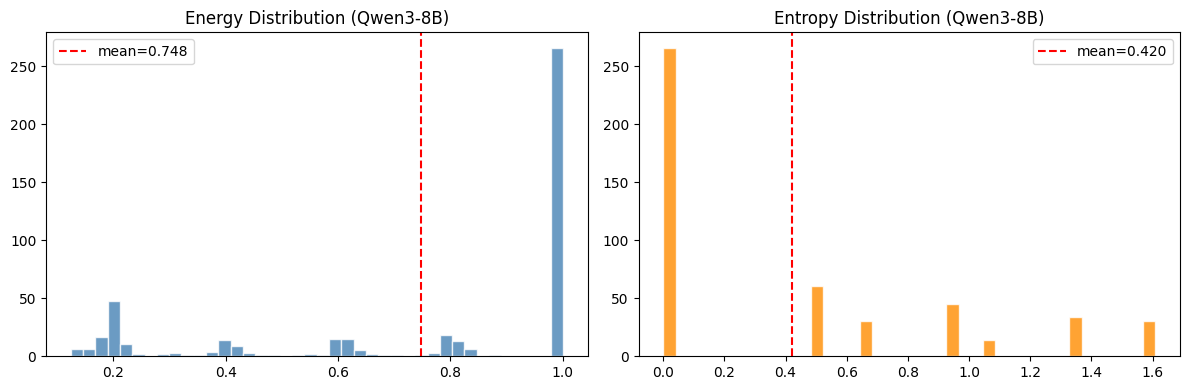

Saved: d:\Github Repositories\SemanticEnergy\backend\data\probe_dataset_qwen3-8b_triviaqa.pkl (555.2 MB)


In [13]:
valid_records = [r for r in records if r['emb_last_tok_before_gen'] is not None]
print(f"Total: {len(records)}, Valid: {len(valid_records)}, Dropped: {len(records)-len(valid_records)}")
es = np.array([r['energy_score_raw'] for r in valid_records])
hs = np.array([r['entropy_score_raw'] for r in valid_records])
cs = np.array([r['correctness'] for r in valid_records])
print(f"Energy:  mean={es.mean():.3f} std={es.std():.3f}")
print(f"Entropy: mean={hs.mean():.3f} std={hs.std():.3f}")
print(f"Correct: {cs.mean():.3f} ({int(cs.sum())}/{len(cs)})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(es, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Energy Distribution ({MODEL_LABEL})')
axes[0].axvline(es.mean(), color='red', linestyle='--', label=f'mean={es.mean():.3f}')
axes[0].legend()
axes[1].hist(hs, bins=40, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_title(f'Entropy Distribution ({MODEL_LABEL})')
axes[1].axvline(hs.mean(), color='red', linestyle='--', label=f'mean={hs.mean():.3f}')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, f'teacher_distributions_{MODEL_SHORT}.png'), dpi=120, bbox_inches='tight')
plt.show()

output_path = os.path.join(DATA_DIR, DATASET_FILE)
with open(output_path, 'wb') as f: pickle.dump(valid_records, f)
print(f"Saved: {output_path} ({os.path.getsize(output_path)/1024**2:.1f} MB)")

## Phase 2 — Probe Training
### 2.1 — Load Dataset & Create Splits

In [14]:
class ProbeDataset:
    def __init__(self, records, name='train'):
        self.name, self.N = name, len(records)
        self.energy_score_raw  = np.array([r['energy_score_raw']  for r in records])
        self.entropy_score_raw = np.array([r['entropy_score_raw'] for r in records])
        self.correctness = np.array([r['correctness'] for r in records])
        self.tbg_states = np.stack([r['emb_last_tok_before_gen'] for r in records])
        self.slt_states = np.stack([r['emb_tok_before_eos']      for r in records])
        self.num_layers = self.tbg_states.shape[1]
        self.hidden_dim = self.tbg_states.shape[2]
        self.logit_feats = np.nan_to_num(np.array([
            [r['logit_feats']['mean_chosen_logit'], r['logit_feats']['min_chosen_logit'],
             r['logit_feats']['std_chosen_logit'], float(r['logit_feats']['answer_len'])]
            for r in records], dtype=np.float64), nan=0., posinf=0., neginf=0.)
        self.energy_label = None
        self.entropy_label = None
        print(f"ProbeDataset '{name}': N={self.N}, layers={self.num_layers}, hidden={self.hidden_dim}")

# Load or use existing valid_records
DATASET_PATH = os.path.join(DATA_DIR, DATASET_FILE)
if 'valid_records' not in dir() or len(valid_records) == 0:
    print(f"Loading: {DATASET_PATH}")
    with open(DATASET_PATH, 'rb') as f:
        valid_records = pickle.load(f)
    print(f"Loaded {len(valid_records)} records")

N = len(valid_records)
idx = np.random.permutation(N)
n_train, n_val = int(0.80 * N), int(0.10 * N)
D_train = ProbeDataset([valid_records[i] for i in idx[:n_train]], 'train')
D_val   = ProbeDataset([valid_records[i] for i in idx[n_train:n_train+n_val]], 'val')
D_test  = ProbeDataset([valid_records[i] for i in idx[n_train+n_val:]], 'test')
print(f"Split: train={D_train.N}, val={D_val.N}, test={D_test.N}")

ProbeDataset 'train': N=384, layers=37, hidden=4096
ProbeDataset 'val': N=48, layers=37, hidden=4096
ProbeDataset 'test': N=48, layers=37, hidden=4096
Split: train=384, val=48, test=48


### 2.2 — Label Binarization
SEP-style: threshold minimizing within-group MSE.

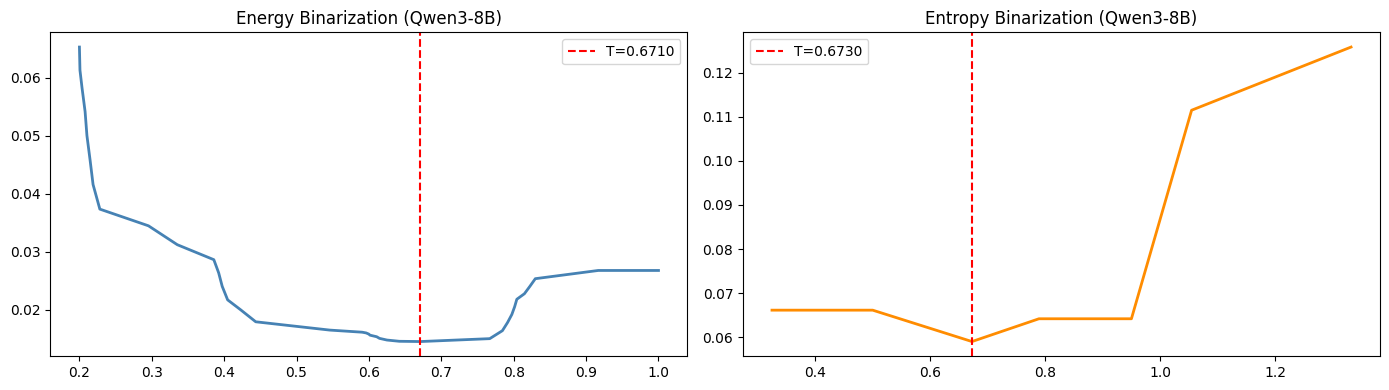

T_energy=0.6710, T_entropy=0.6730
energy_label balance:
  train: 0.648 positive
  val: 0.604 positive
  test: 0.667 positive
entropy_label balance:
  train: 0.328 positive
  val: 0.312 positive
  test: 0.250 positive


In [15]:
def find_best_threshold(scores):
    best_thresh, best_mse = None, float('inf')
    thresholds, mses = [], []
    for pct in np.arange(10, 91, 1):
        thresh = np.percentile(scores, pct)
        g0, g1 = scores[scores < thresh], scores[scores >= thresh]
        if len(g0) == 0 or len(g1) == 0: continue
        mse = (len(g0) * g0.var() + len(g1) * g1.var()) / len(scores)
        thresholds.append(thresh); mses.append(mse)
        if mse < best_mse: best_mse, best_thresh = mse, thresh
    return best_thresh, np.array(thresholds), np.array(mses)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
T_energy, et, em = find_best_threshold(D_train.energy_score_raw)
axes[0].plot(et, em, color='steelblue', lw=2)
axes[0].axvline(T_energy, color='red', ls='--', label=f'T={T_energy:.4f}')
axes[0].set_title(f'Energy Binarization ({MODEL_LABEL})'); axes[0].legend()

T_entropy, ht, hm = find_best_threshold(D_train.entropy_score_raw)
axes[1].plot(ht, hm, color='darkorange', lw=2)
axes[1].axvline(T_entropy, color='red', ls='--', label=f'T={T_entropy:.4f}')
axes[1].set_title(f'Entropy Binarization ({MODEL_LABEL})'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, f'binarization_sweep_{MODEL_SHORT}.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"T_energy={T_energy:.4f}, T_entropy={T_entropy:.4f}")

for D in [D_train, D_val, D_test]:
    D.energy_label  = (D.energy_score_raw  >= T_energy).astype(int)
    D.entropy_label = (D.entropy_score_raw >= T_entropy).astype(int)

for lbl in ['energy_label', 'entropy_label']:
    print(f"{lbl} balance:")
    for D in [D_train, D_val, D_test]:
        print(f"  {D.name}: {getattr(D, lbl).mean():.3f} positive")

### 2.3 — Training Helper Functions

In [16]:
def get_layer_X(D, layer, token='slt'):
    return (D.slt_states if token == 'slt' else D.tbg_states)[:, layer, :]

def get_range_X(D, lr, token='slt'):
    return (D.slt_states if token == 'slt' else D.tbg_states)[:, lr[0]:lr[1], :].reshape(D.N, -1)

def clean_X(X):
    return np.nan_to_num(np.array(X, dtype=np.float64), nan=0., posinf=0., neginf=0.)

def sklearn_train_eval(Xtr, ytr, Xv, yv, scale=True):
    Xtr, Xv = clean_X(Xtr), clean_X(Xv)
    scaler = StandardScaler().fit(Xtr) if scale else None
    if scaler: Xtr, Xv = scaler.transform(Xtr), scaler.transform(Xv)
    probe = LogisticRegression(max_iter=1000, C=1.0).fit(Xtr, ytr)
    return probe, scaler, roc_auc_score(yv, probe.predict_proba(Xv)[:, 1])

def save_fig(name):
    p = os.path.join(FIGS_DIR, f'{name}_{MODEL_SHORT}.png')
    plt.savefig(p, dpi=120, bbox_inches='tight')
    print(f"Saved: {p}")

print("Training helpers defined.")

Training helpers defined.


### 2.4 — Per-Layer AUROC Sweep — Energy Probe

Energy layer sweep:   0%|          | 0/37 [00:00<?, ?it/s]

SLT best: layer 23, AUROC=0.8421
TBG best: layer 16, AUROC=0.7060
Saved: d:\Github Repositories\SemanticEnergy\notebooks\figures\energy_layer_sweep_qwen3-8b.png


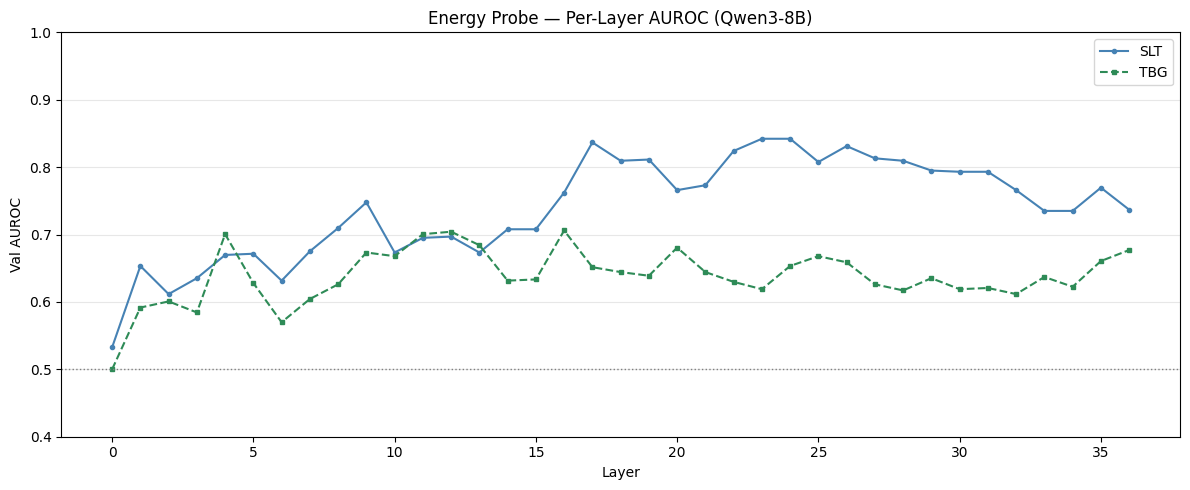

In [17]:
num_layers = D_train.num_layers
energy_slt_aurocs, energy_tbg_aurocs = [], []
for layer in tqdm(range(num_layers), desc='Energy layer sweep'):
    _, _, a_slt = sklearn_train_eval(get_layer_X(D_train, layer, 'slt'), D_train.energy_label,
                                      get_layer_X(D_val, layer, 'slt'), D_val.energy_label)
    _, _, a_tbg = sklearn_train_eval(get_layer_X(D_train, layer, 'tbg'), D_train.energy_label,
                                      get_layer_X(D_val, layer, 'tbg'), D_val.energy_label)
    energy_slt_aurocs.append(a_slt); energy_tbg_aurocs.append(a_tbg)
print(f"SLT best: layer {np.argmax(energy_slt_aurocs)}, AUROC={max(energy_slt_aurocs):.4f}")
print(f"TBG best: layer {np.argmax(energy_tbg_aurocs)}, AUROC={max(energy_tbg_aurocs):.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(num_layers), energy_slt_aurocs, marker='o', ms=3, label='SLT', color='steelblue')
ax.plot(range(num_layers), energy_tbg_aurocs, marker='s', ms=3, label='TBG', color='seagreen', ls='--')
ax.axhline(0.5, color='gray', ls=':', lw=1); ax.set_ylim(0.4, 1.0)
ax.set_xlabel('Layer'); ax.set_ylabel('Val AUROC')
ax.set_title(f'Energy Probe — Per-Layer AUROC ({MODEL_LABEL})'); ax.legend()
ax.grid(axis='y', alpha=0.3); plt.tight_layout()
save_fig('energy_layer_sweep'); plt.show()

### 2.5 — Per-Layer AUROC Sweep — Entropy Probe

Entropy layer sweep:   0%|          | 0/37 [00:00<?, ?it/s]

SLT best: layer 28, AUROC=0.8808
TBG best: layer 11, AUROC=0.7636
Saved: d:\Github Repositories\SemanticEnergy\notebooks\figures\entropy_layer_sweep_qwen3-8b.png


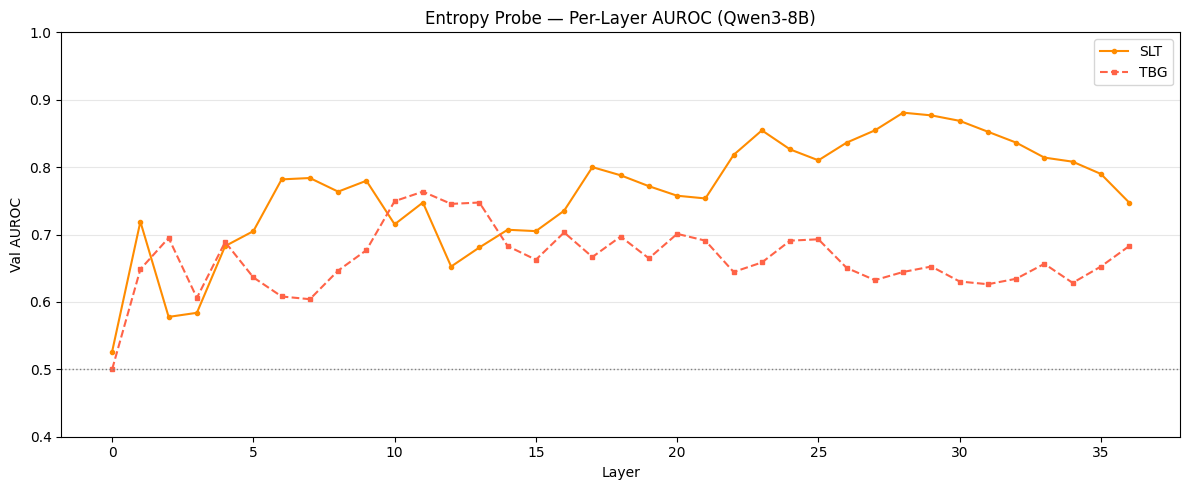

In [18]:
entropy_slt_aurocs, entropy_tbg_aurocs = [], []
for layer in tqdm(range(num_layers), desc='Entropy layer sweep'):
    _, _, a_slt = sklearn_train_eval(get_layer_X(D_train, layer, 'slt'), D_train.entropy_label,
                                      get_layer_X(D_val, layer, 'slt'), D_val.entropy_label)
    _, _, a_tbg = sklearn_train_eval(get_layer_X(D_train, layer, 'tbg'), D_train.entropy_label,
                                      get_layer_X(D_val, layer, 'tbg'), D_val.entropy_label)
    entropy_slt_aurocs.append(a_slt); entropy_tbg_aurocs.append(a_tbg)
print(f"SLT best: layer {np.argmax(entropy_slt_aurocs)}, AUROC={max(entropy_slt_aurocs):.4f}")
print(f"TBG best: layer {np.argmax(entropy_tbg_aurocs)}, AUROC={max(entropy_tbg_aurocs):.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(num_layers), entropy_slt_aurocs, marker='o', ms=3, label='SLT', color='darkorange')
ax.plot(range(num_layers), entropy_tbg_aurocs, marker='s', ms=3, label='TBG', color='tomato', ls='--')
ax.axhline(0.5, color='gray', ls=':', lw=1); ax.set_ylim(0.4, 1.0)
ax.set_xlabel('Layer'); ax.set_ylabel('Val AUROC')
ax.set_title(f'Entropy Probe — Per-Layer AUROC ({MODEL_LABEL})'); ax.legend()
ax.grid(axis='y', alpha=0.3); plt.tight_layout()
save_fig('entropy_layer_sweep'); plt.show()

### 2.6 — Layer Range Selection

In [19]:
def decide_layer_range(auroc_list, window_sizes=[4, 8, 16]):
    aucs = np.array(auroc_list)
    best_mean, best_range = -np.inf, (0, 4)
    for w in window_sizes:
        for s in range(len(aucs) - w + 1):
            m = aucs[s:s+w].mean()
            if m > best_mean: best_mean, best_range = m, (s, s+w)
    return best_mean, best_range

_, best_energy_slt_range  = decide_layer_range(energy_slt_aurocs)
_, best_energy_tbg_range  = decide_layer_range(energy_tbg_aurocs)
_, best_entropy_slt_range = decide_layer_range(entropy_slt_aurocs)
_, best_entropy_tbg_range = decide_layer_range(entropy_tbg_aurocs)
print("Best layer ranges:")
for n, r in [('Energy SLT', best_energy_slt_range), ('Energy TBG', best_energy_tbg_range),
             ('Entropy SLT', best_entropy_slt_range), ('Entropy TBG', best_entropy_tbg_range)]:
    print(f"  {n}: {r}")

Best layer ranges:
  Energy SLT: (23, 27)
  Energy TBG: (10, 14)
  Entropy SLT: (27, 31)
  Entropy TBG: (10, 14)


### 2.7 — Feature Ablation

In [20]:
print(f"{'Probe':<22} {'Hidden':>10} {'Logit':>10} {'H+L':>10}")
print("-" * 55)
for name, lk, tok, lr in [('Energy SLT', 'energy_label', 'slt', best_energy_slt_range),
                            ('Energy TBG', 'energy_label', 'tbg', best_energy_tbg_range),
                            ('Entropy SLT', 'entropy_label', 'slt', best_entropy_slt_range),
                            ('Entropy TBG', 'entropy_label', 'tbg', best_entropy_tbg_range)]:
    yt, yv = getattr(D_train, lk), getattr(D_val, lk)
    Xh_tr, Xh_v = get_range_X(D_train, lr, tok), get_range_X(D_val, lr, tok)
    _, _, ah = sklearn_train_eval(Xh_tr, yt, Xh_v, yv)
    _, _, al = sklearn_train_eval(D_train.logit_feats, yt, D_val.logit_feats, yv)
    sh, sl = StandardScaler(), StandardScaler()
    Xc_tr = np.concatenate([sh.fit_transform(Xh_tr), sl.fit_transform(D_train.logit_feats)], 1)
    Xc_v  = np.concatenate([sh.transform(Xh_v), sl.transform(D_val.logit_feats)], 1)
    p = LogisticRegression(max_iter=1000).fit(Xc_tr, yt)
    ahl = roc_auc_score(yv, p.predict_proba(Xc_v)[:, 1])
    print(f"{name:<22} {ah:>10.4f} {al:>10.4f} {ahl:>10.4f}")

Probe                      Hidden      Logit        H+L
-------------------------------------------------------
Energy SLT                 0.8439     0.8457     0.8512
Energy TBG                 0.6897     0.8457     0.7060
Entropy SLT                0.8707     0.7919     0.8747
Entropy TBG                0.7717     0.7919     0.7737


### 2.8 — Train Final Probes

In [21]:
trained_probes = {}
configs = [('slt_energy', 'energy_label', 'slt', best_energy_slt_range),
           ('tbg_energy', 'energy_label', 'tbg', best_energy_tbg_range),
           ('slt_entropy', 'entropy_label', 'slt', best_entropy_slt_range),
           ('tbg_entropy', 'entropy_label', 'tbg', best_entropy_tbg_range)]

for pname, lk, tok, lr in configs:
    yt, yv = getattr(D_train, lk), getattr(D_val, lk)
    probe, scaler, val_auc = sklearn_train_eval(get_range_X(D_train, lr, tok), yt,
                                                 get_range_X(D_val, lr, tok), yv)
    trained_probes[pname] = {'probe': probe, 'scaler': scaler, 'layer_range': lr, 'token': tok}
    print(f"{pname:<15}: val AUROC = {val_auc:.4f}")

slt_energy     : val AUROC = 0.8439
tbg_energy     : val AUROC = 0.6897
slt_entropy    : val AUROC = 0.8707
tbg_entropy    : val AUROC = 0.7717


## Phase 3 — Comprehensive Evaluation
A thorough evaluation of all trained probes on the held-out test set.

**Metrics computed:**
- **AUROC** (Area Under ROC Curve) — discriminative ability
- **AUPR** (Area Under Precision-Recall Curve) — performance under class imbalance
- **FPR@95** (False Positive Rate at 95% True Positive Rate) — practical misdetection rate
- **Bootstrap 95% CIs** for all metrics
- **Teacher fidelity** (Spearman ρ with raw teacher)
- **Hallucination detection** comparison with teacher upper bounds

### 3.1 — Evaluation Functions

In [22]:
def fpr_at_tpr(y_true, y_score, target_tpr=0.95):
    """Compute FPR at a given TPR threshold (e.g., FPR@95)."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    # Find the threshold where TPR >= target_tpr
    idx = np.where(tpr >= target_tpr)[0]
    if len(idx) == 0:
        return 1.0  # worst case
    return float(fpr[idx[0]])

def full_eval(y_true, y_score):
    """Compute AUROC, AUPR, and FPR@95 for a single set of predictions."""
    auroc = roc_auc_score(y_true, y_score)
    aupr  = average_precision_score(y_true, y_score)
    fpr95 = fpr_at_tpr(y_true, y_score, 0.95)
    return {'auroc': auroc, 'aupr': aupr, 'fpr95': fpr95}

def bootstrap_full_eval(y_true, y_score, n_boot=1000, ci=0.95):
    """Bootstrap 95% CI for AUROC, AUPR, and FPR@95."""
    base = full_eval(y_true, y_score)
    boot = {'auroc': [], 'aupr': [], 'fpr95': []}
    rng = np.random.default_rng(0)
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2: continue
        b = full_eval(y_true[idx], y_score[idx])
        for k in boot: boot[k].append(b[k])
    alpha = (1 - ci) / 2
    result = {}
    for k in base:
        result[k] = {
            'mean': base[k],
            'lo': np.percentile(boot[k], alpha * 100),
            'hi': np.percentile(boot[k], (1 - alpha) * 100),
        }
    return result

print("Evaluation functions defined.")

Evaluation functions defined.


### 3.2 — In-Distribution Probe Evaluation (Test Set)

In [23]:
print("=" * 80)
print(f"COMPREHENSIVE EVALUATION — {MODEL_LABEL} on {DATASET_NAME}")
print("=" * 80)
print()

eval_results = {}
print(f"{'Probe':<15} {'AUROC':>8} {'95% CI':>16} {'AUPR':>8} {'95% CI':>16} {'FPR@95':>8} {'95% CI':>16}")
print("-" * 90)

for pname, lk, tok, lr in configs:
    y_test = getattr(D_test, lk)
    X_test = get_range_X(D_test, lr, tok)
    p_info = trained_probes[pname]
    X_test_s = p_info['scaler'].transform(clean_X(X_test))
    y_score = p_info['probe'].predict_proba(X_test_s)[:, 1]
    
    res = bootstrap_full_eval(y_test, y_score)
    eval_results[pname] = res
    
    print(f"{pname:<15} "
          f"{res['auroc']['mean']:>8.4f} [{res['auroc']['lo']:.4f}, {res['auroc']['hi']:.4f}]  "
          f"{res['aupr']['mean']:>8.4f} [{res['aupr']['lo']:.4f}, {res['aupr']['hi']:.4f}]  "
          f"{res['fpr95']['mean']:>8.4f} [{res['fpr95']['lo']:.4f}, {res['fpr95']['hi']:.4f}]")

COMPREHENSIVE EVALUATION — Qwen3-8B on trivia_qa

Probe              AUROC           95% CI     AUPR           95% CI   FPR@95           95% CI
------------------------------------------------------------------------------------------
slt_energy        0.9492 [0.8769, 1.0000]    0.9748 [0.9352, 1.0000]    0.1875 [0.0000, 0.7333]
tbg_energy        0.7246 [0.5616, 0.8594]    0.8805 [0.7774, 0.9511]    1.0000 [0.8180, 1.0000]
slt_entropy       0.8380 [0.6646, 0.9631]    0.7083 [0.4335, 0.9072]    0.7500 [0.0833, 0.8824]
tbg_entropy       0.7384 [0.5822, 0.8635]    0.3879 [0.2286, 0.6296]    0.5833 [0.2000, 0.7297]


### 3.3 — Teacher Fidelity (Spearman ρ)

In [24]:
print(f"{'Probe':<15} {'Teacher':<20} {'Spearman rho':>12} {'p-value':>12}")
print("-" * 62)
for pname, lk, tok, lr in configs:
    teacher_key = 'energy_score_raw' if 'energy' in pname else 'entropy_score_raw'
    raw_teacher = getattr(D_test, teacher_key)
    X_test = get_range_X(D_test, lr, tok)
    p_info = trained_probes[pname]
    probe_score = p_info['probe'].predict_proba(p_info['scaler'].transform(clean_X(X_test)))[:, 1]
    rho, p = spearmanr(probe_score, raw_teacher)
    print(f"{pname:<15} {teacher_key:<20} {rho:>12.4f} {p:>12.2e}")

Probe           Teacher              Spearman rho      p-value
--------------------------------------------------------------
slt_energy      energy_score_raw           0.7363     2.46e-09
tbg_energy      energy_score_raw           0.3920     5.86e-03
slt_entropy     entropy_score_raw          0.6517     5.24e-07
tbg_entropy     entropy_score_raw          0.4077     4.02e-03


### 3.4 — Full Teacher Upper Bounds

In [25]:
y_hall = 1 - D_test.correctness
energy_ub  = full_eval(y_hall, 1 - D_test.energy_score_raw)
entropy_ub = full_eval(y_hall, D_test.entropy_score_raw)

print("Full teacher upper bounds (test set):")
print(f"  Energy teacher:  AUROC={energy_ub['auroc']:.4f}  AUPR={energy_ub['aupr']:.4f}  FPR@95={energy_ub['fpr95']:.4f}")
print(f"  Entropy teacher: AUROC={entropy_ub['auroc']:.4f}  AUPR={entropy_ub['aupr']:.4f}  FPR@95={entropy_ub['fpr95']:.4f}")
print()
print("Note: probes approximate these with a single forward pass instead of 5-sample generation + clustering.")

Full teacher upper bounds (test set):
  Energy teacher:  AUROC=0.8523  AUPR=0.8683  FPR@95=1.0000
  Entropy teacher: AUROC=0.8444  AUPR=0.8580  FPR@95=1.0000

Note: probes approximate these with a single forward pass instead of 5-sample generation + clustering.


### 3.5 — Hallucination Detection — All Systems Comparison

In [26]:
def get_hall_score(pname, p_info, D_test):
    X = get_range_X(D_test, p_info['layer_range'], p_info['token'])
    s = p_info['probe'].predict_proba(p_info['scaler'].transform(clean_X(X)))[:, 1]
    return 1 - s if 'energy' in pname else s

logit_probe = LogisticRegression(max_iter=1000).fit(D_train.logit_feats, D_train.energy_label)
logit_score = 1 - logit_probe.predict_proba(D_test.logit_feats)[:, 1]

systems = [
    ('Energy teacher (UB)',  1 - D_test.energy_score_raw),
    ('Entropy teacher (UB)', D_test.entropy_score_raw),
    ('SLT energy probe',     get_hall_score('slt_energy', trained_probes['slt_energy'], D_test)),
    ('TBG energy probe',     get_hall_score('tbg_energy', trained_probes['tbg_energy'], D_test)),
    ('SLT entropy probe',    get_hall_score('slt_entropy', trained_probes['slt_entropy'], D_test)),
    ('TBG entropy probe',    get_hall_score('tbg_entropy', trained_probes['tbg_entropy'], D_test)),
    ('Logit features only',  logit_score),
]

print(f"{'System':<30} {'AUROC':>8} {'AUPR':>8} {'FPR@95':>8}")
print("-" * 60)
sys_results = []
for name, scores in systems:
    r = full_eval(y_hall, scores)
    sys_results.append((name, r))
    print(f"{name:<30} {r['auroc']:>8.4f} {r['aupr']:>8.4f} {r['fpr95']:>8.4f}")

System                            AUROC     AUPR   FPR@95
------------------------------------------------------------
Energy teacher (UB)              0.8523   0.8683   1.0000
Entropy teacher (UB)             0.8444   0.8580   1.0000
SLT energy probe                 0.8934   0.9231   0.4545
TBG energy probe                 0.6643   0.6664   0.8182
SLT entropy probe                0.8724   0.9242   0.8182
TBG entropy probe                0.7010   0.6867   0.9091
Logit features only              0.7867   0.8627   1.0000


### 3.6 — Confusion Matrices
Confusion matrices for each probe system at the optimal threshold (Youden's J statistic).
Shows True Positives, False Positives, True Negatives, and False Negatives for hallucination detection.

Saved: d:\Github Repositories\SemanticEnergy\notebooks\figures\confusion_matrices_qwen3-8b.png


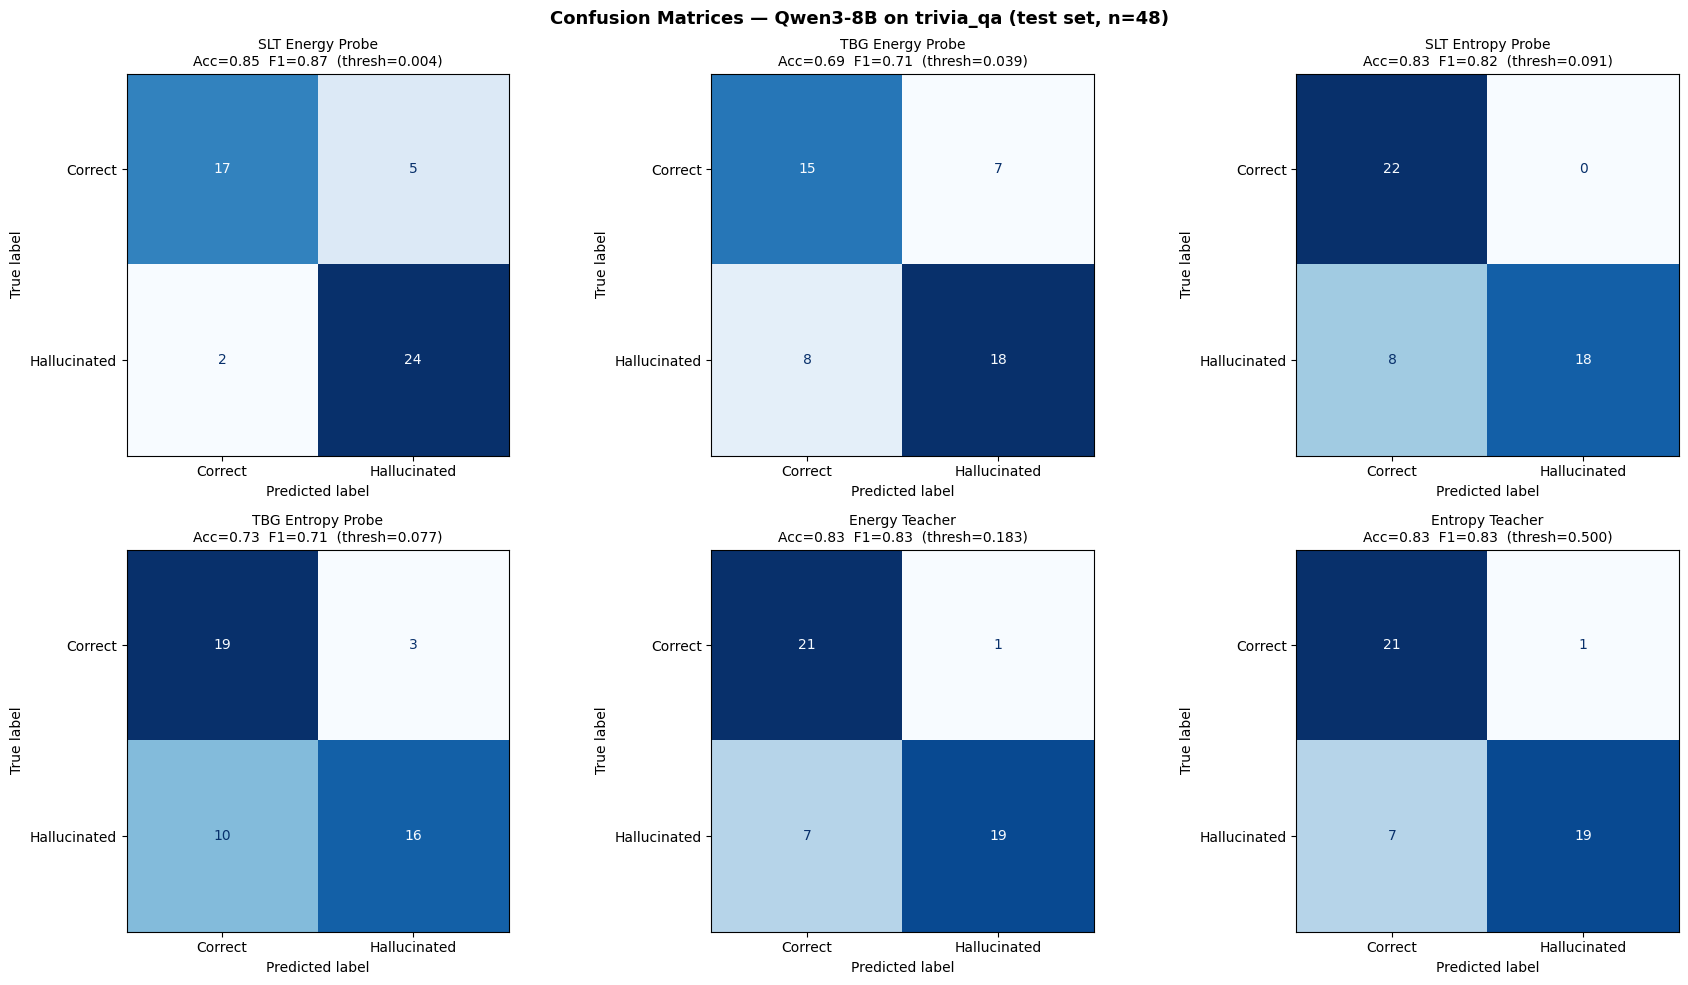


System                   TP   FP   TN   FN    Acc   Prec    Rec     F1
------------------------------------------------------------------------
SLT Energy Probe         24    5   17    2  0.854  0.828  0.923  0.873
TBG Energy Probe         18    7   15    8  0.688  0.720  0.692  0.706
SLT Entropy Probe        18    0   22    8  0.833  1.000  0.692  0.818
TBG Entropy Probe        16    3   19   10  0.729  0.842  0.615  0.711
Energy Teacher           19    1   21    7  0.833  0.950  0.731  0.826
Entropy Teacher          19    1   21    7  0.833  0.950  0.731  0.826


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def optimal_threshold(y_true, y_score):
    """Find optimal threshold using Youden's J statistic (maximizes TPR - FPR)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    j = tpr - fpr
    best_idx = np.argmax(j)
    return thresholds[best_idx]

# Hallucination labels: 1 = hallucinated, 0 = correct
y_hall = 1 - D_test.correctness

# Systems to plot
cm_systems = [
    ('SLT Energy Probe',  get_hall_score('slt_energy', trained_probes['slt_energy'], D_test)),
    ('TBG Energy Probe',  get_hall_score('tbg_energy', trained_probes['tbg_energy'], D_test)),
    ('SLT Entropy Probe', get_hall_score('slt_entropy', trained_probes['slt_entropy'], D_test)),
    ('TBG Entropy Probe', get_hall_score('tbg_entropy', trained_probes['tbg_entropy'], D_test)),
    ('Energy Teacher',    1 - D_test.energy_score_raw),
    ('Entropy Teacher',   D_test.entropy_score_raw),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cm_summary = []
for ax, (name, scores) in zip(axes, cm_systems):
    thresh = optimal_threshold(y_hall.astype(int), scores)
    y_pred = (scores >= thresh).astype(int)
    cm = confusion_matrix(y_hall.astype(int), y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Correct', 'Hallucinated'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    ax.set_title(f'{name}\nAcc={accuracy:.2f}  F1={f1:.2f}  (thresh={thresh:.3f})', fontsize=10)
    cm_summary.append({'System': name, 'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
                       'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1})

plt.suptitle(f'Confusion Matrices \u2014 {MODEL_LABEL} on {DATASET_NAME} (test set, n={len(y_hall)})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('confusion_matrices')
plt.show()

# Summary table
print(f"\n{'System':<22} {'TP':>4} {'FP':>4} {'TN':>4} {'FN':>4} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print('-' * 72)
for r in cm_summary:
    print(f"{r['System']:<22} {r['TP']:>4} {r['FP']:>4} {r['TN']:>4} {r['FN']:>4} "
          f"{r['Accuracy']:>6.3f} {r['Precision']:>6.3f} {r['Recall']:>6.3f} {r['F1']:>6.3f}")

### 3.7 — Performance Comparison Plots

Saved: d:\Github Repositories\SemanticEnergy\notebooks\figures\performance_comparison_qwen3-8b.png


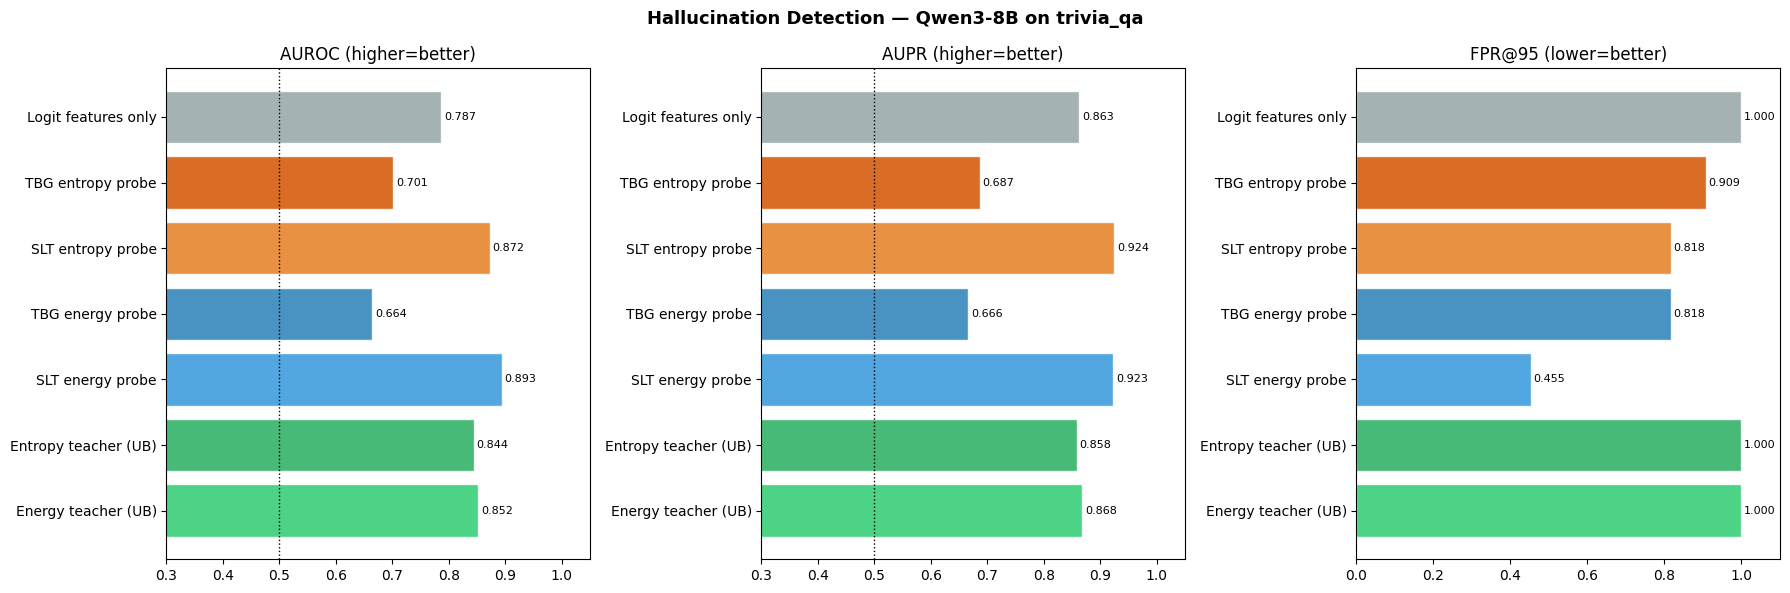

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
names  = [s[0] for s in sys_results]
colors = ['#2ecc71', '#27ae60', '#3498db', '#2980b9', '#e67e22', '#d35400', '#95a5a6']

for ax, metric, title in zip(axes, ['auroc', 'aupr', 'fpr95'],
                              ['AUROC (higher=better)', 'AUPR (higher=better)', 'FPR@95 (lower=better)']):
    vals = [s[1][metric] for s in sys_results]
    bars = ax.barh(names, vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
    if metric == 'fpr95':
        ax.set_xlim(0, 1.1)
    else:
        ax.axvline(0.5, color='black', ls=':', lw=1)
        ax.set_xlim(0.3, 1.05)
    ax.set_title(title)

plt.suptitle(f'Hallucination Detection — {MODEL_LABEL} on {DATASET_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('performance_comparison'); plt.show()

### 3.8 — ROC and Precision-Recall Curves

Saved: d:\Github Repositories\SemanticEnergy\notebooks\figures\roc_pr_curves_qwen3-8b.png


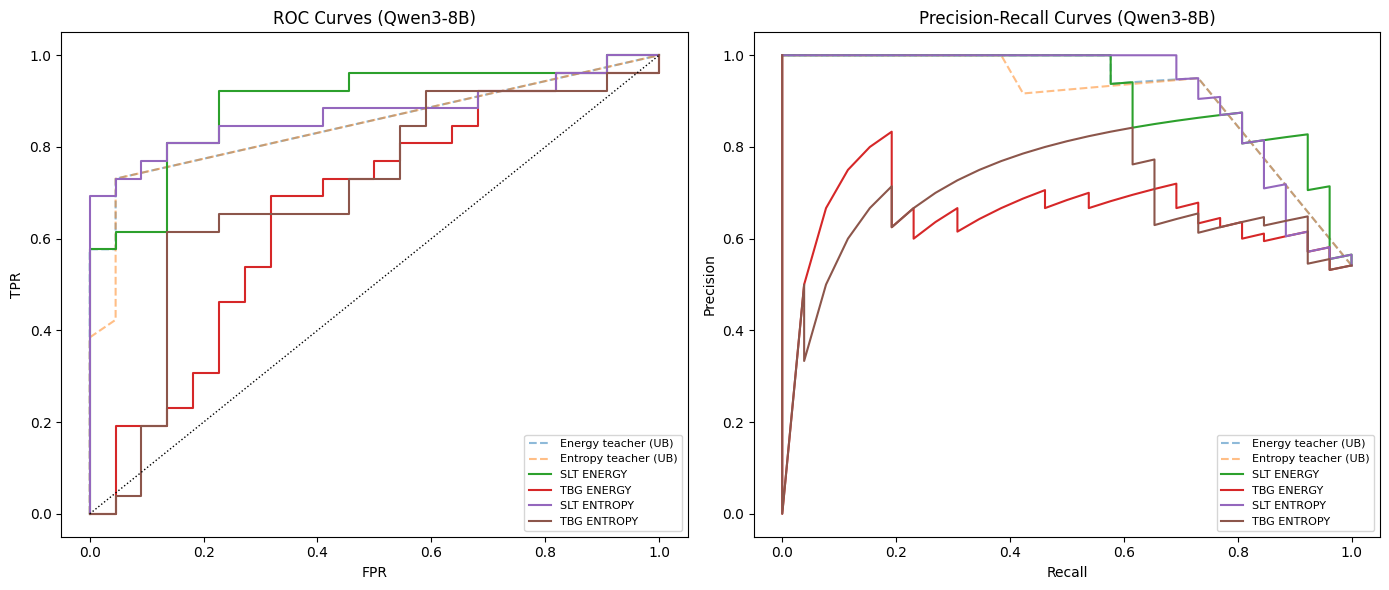

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
probe_colors = {'SLT energy': '#3498db', 'TBG energy': '#2980b9',
                'SLT entropy': '#e67e22', 'TBG entropy': '#d35400'}

# ROC curves
ax = axes[0]
for name, scores in systems[:2]:  # Teachers
    fpr, tpr, _ = roc_curve(y_hall, scores)
    ax.plot(fpr, tpr, ls='--', alpha=0.5, label=name)
for pname in ['slt_energy', 'tbg_energy', 'slt_entropy', 'tbg_entropy']:
    scores = get_hall_score(pname, trained_probes[pname], D_test)
    fpr, tpr, _ = roc_curve(y_hall, scores)
    label = pname.replace('_', ' ').upper()
    ax.plot(fpr, tpr, label=label)
ax.plot([0,1], [0,1], 'k:', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC Curves ({MODEL_LABEL})'); ax.legend(fontsize=8)

# PR curves
ax = axes[1]
for name, scores in systems[:2]:
    prec, rec, _ = precision_recall_curve(y_hall, scores)
    ax.plot(rec, prec, ls='--', alpha=0.5, label=name)
for pname in ['slt_energy', 'tbg_energy', 'slt_entropy', 'tbg_entropy']:
    scores = get_hall_score(pname, trained_probes[pname], D_test)
    prec, rec, _ = precision_recall_curve(y_hall, scores)
    ax.plot(rec, prec, label=pname.replace('_', ' ').upper())
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curves ({MODEL_LABEL})'); ax.legend(fontsize=8)

plt.tight_layout()
save_fig('roc_pr_curves'); plt.show()

### 3.9 — Cross-Signal Analysis

In [30]:
rho_cross, p_cross = spearmanr(D_test.energy_score_raw, D_test.entropy_score_raw)
print(f"rho(energy_raw, entropy_raw): {rho_cross:.4f} (p={p_cross:.2e})")
print("Expected: negative (high energy = low entropy)")

X_e = get_range_X(D_test, best_energy_slt_range, 'slt')
X_h = get_range_X(D_test, best_entropy_slt_range, 'slt')
e_s = trained_probes['slt_energy']['probe'].predict_proba(
    trained_probes['slt_energy']['scaler'].transform(clean_X(X_e)))[:, 1]
h_s = trained_probes['slt_entropy']['probe'].predict_proba(
    trained_probes['slt_entropy']['scaler'].transform(clean_X(X_h)))[:, 1]
rho_p, _ = spearmanr(e_s, h_s)
print(f"rho(energy_probe, entropy_probe): {rho_p:.4f}")

rho(energy_raw, entropy_raw): -0.9566 (p=2.83e-26)
Expected: negative (high energy = low entropy)
rho(energy_probe, entropy_probe): -0.8844


### 3.10 — Efficiency Summary

In [31]:
print("Efficiency comparison (estimates):")
print(f"  Full teacher (5 gen + clustering): ~60-120s per question")
print(f"  SLT probe (1 gen + 1 fwd pass):   ~5-15s per question")
print(f"  TBG probe (0 gen + 1 fwd pass):    ~0.5-2s per question  <- fastest")
print()
print("Probe speedup over full teacher: ~10-60x")

Efficiency comparison (estimates):
  Full teacher (5 gen + clustering): ~60-120s per question
  SLT probe (1 gen + 1 fwd pass):   ~5-15s per question
  TBG probe (0 gen + 1 fwd pass):    ~0.5-2s per question  <- fastest

Probe speedup over full teacher: ~10-60x


### 3.11 — Save Probe Bundle

In [32]:
probe_bundle = {
    'model_id': MODEL_ID, 'dataset': DATASET_NAME,
    'num_train_records': D_train.N,
    'energy_threshold': T_energy, 'entropy_threshold': T_entropy,
    'best_energy_slt_range': best_energy_slt_range, 'best_energy_tbg_range': best_energy_tbg_range,
    'best_entropy_slt_range': best_entropy_slt_range, 'best_entropy_tbg_range': best_entropy_tbg_range,
    'slt_energy_probe': trained_probes['slt_energy']['probe'],
    'slt_energy_scaler': trained_probes['slt_energy']['scaler'],
    'tbg_energy_probe': trained_probes['tbg_energy']['probe'],
    'tbg_energy_scaler': trained_probes['tbg_energy']['scaler'],
    'slt_entropy_probe': trained_probes['slt_entropy']['probe'],
    'slt_entropy_scaler': trained_probes['slt_entropy']['scaler'],
    'tbg_entropy_probe': trained_probes['tbg_entropy']['probe'],
    'tbg_entropy_scaler': trained_probes['tbg_entropy']['scaler'],
    'layer_auroc_table': {
        'energy_slt': energy_slt_aurocs, 'energy_tbg': energy_tbg_aurocs,
        'entropy_slt': entropy_slt_aurocs, 'entropy_tbg': entropy_tbg_aurocs,
    },
    'eval_results': eval_results,
}

out = os.path.join(MODELS_DIR, PROBE_FILE)
with open(out, 'wb') as f: pickle.dump(probe_bundle, f)
print(f"Probe bundle saved: {out} ({os.path.getsize(out)/1024:.0f} KB)")
print("\nContents:")
for k, v in probe_bundle.items():
    if hasattr(v, '__class__') and 'Logistic' in type(v).__name__: print(f"  {k}: LogisticRegression")
    else: print(f"  {k}: {repr(v)[:60]}")
print("\nReady for deployment via engine.py")

Probe bundle saved: d:\Github Repositories\SemanticEnergy\backend\models\probes_qwen3-8b_triviaqa.pkl (2053 KB)

Contents:
  model_id: 'Qwen/Qwen3-8B'
  dataset: 'trivia_qa'
  num_train_records: 384
  energy_threshold: np.float64(0.6710437081916832)
  entropy_threshold: np.float64(0.6730116668092565)
  best_energy_slt_range: (23, 27)
  best_energy_tbg_range: (10, 14)
  best_entropy_slt_range: (27, 31)
  best_entropy_tbg_range: (10, 14)
  slt_energy_probe: LogisticRegression
  slt_energy_scaler: StandardScaler()
  tbg_energy_probe: LogisticRegression
  tbg_energy_scaler: StandardScaler()
  slt_entropy_probe: LogisticRegression
  slt_entropy_scaler: StandardScaler()
  tbg_entropy_probe: LogisticRegression
  tbg_entropy_scaler: StandardScaler()
  layer_auroc_table: {'energy_slt': [0.5326678765880217, 0.6533575317604355, 0.61
  eval_results: {'slt_energy': {'auroc': {'mean': 0.94921875, 'lo': np.float

Ready for deployment via engine.py


## Phase 4 — Sentence-Level Logit Baseline (B1)
> This is a lightweight single-pass approximation — NOT Semantic Energy.
> No clustering, no multi-sample generation.

In [33]:
import pysbd
segmenter = pysbd.Segmenter(language='en', clean=False)

def split_sentences(text):
    return [s.strip() for s in segmenter.segment(text) if s.strip()]

def align_tokens(tokenizer, text, token_ids, sentences):
    enc = tokenizer(text, return_offsets_mapping=True, add_special_tokens=False)
    offsets = enc['offset_mapping']
    spans, pos = [], 0
    for s in sentences:
        start = text.find(s, pos)
        if start == -1: start = pos
        spans.append((start, start + len(s))); pos = start + len(s)
    result = []
    for i in range(min(len(token_ids), len(offsets))):
        cs, ce = offsets[i]
        mid = (cs + ce) // 2
        si = len(sentences) - 1
        for j, (ss, se) in enumerate(spans):
            if ss <= mid < se: si = j; break
        result.append(si)
    return result

question = "Tell me about the history of the Eiffel Tower."
gen_data = engine.generate_responses(question, num_samples=1)
answer = gen_data[0]['answer']
logits = gen_data[0]['logits']
tids = gen_data[0]['token_ids']
top2 = gen_data[0].get('top2_logits', None)

sentences = split_sentences(answer)
tok_sent = align_tokens(engine.tokenizer, answer, tids, sentences)

print(f"Question: {question}")
print(f"Answer ({len(tids)} tokens, {len(sentences)} sentences):")
for i, s in enumerate(sentences):
    tokens = [j for j, si in enumerate(tok_sent) if si == i]
    if not tokens: continue
    sl = [logits[j] for j in tokens if j < len(logits)]
    ml = float(np.mean(sl)) if sl else 0.
    print(f"  [{i}] logit={ml:+.2f} | {s[:90]}")
print("\nB1 sentence baseline demo complete.")

  [Sample 1/1] The Eiffel Tower was built for the 1889 Exposition Universelle in Paris to comme...
Question: Tell me about the history of the Eiffel Tower.
Answer (113 tokens, 5 sentences):
  [0] logit=+62.80 | The Eiffel Tower was built for the 1889 Exposition Universelle in Paris to commemorate the
  [1] logit=+59.93 | Designed by engineer Gustave Eiffel and his team, it was completed in 1889 and initially c
  [2] logit=+61.14 | However, it became a symbol of France and a global icon of engineering and architecture.
  [3] logit=+57.56 | It was originally intended to be a temporary structure, but its popularity led to its pres
  [4] logit=+65.15 | Today, it is one of the most visited landmarks in the world.

B1 sentence baseline demo complete.


## Summary
This notebook has completed the full probe training pipeline:

1. **Pre-flight**: Verified Energy and Entropy formulas and score orientations
2. **Dataset**: Generated probe dataset with hidden states, teacher signals, and correctness labels
3. **Training**: Trained 4 probes (SLT/TBG × Energy/Entropy) with layer sweeps and ablation
4. **Evaluation**: Comprehensive metrics (AUROC, AUPR, FPR@95) with bootstrap CIs, ROC/PR curves
5. **Sentence Baseline**: B1 logit-confidence demo

### Deliverables
- `backend/data/{DATASET_FILE}` — Probe dataset
- `backend/models/{PROBE_FILE}` — Trained probe bundle (used by `engine.py` for inference)
- `notebooks/figures/` — All evaluation figures

### Using in the Framework
The probe bundle is loaded by `engine.py`:
- `score_with_tbg_probe()` — Pre-generation risk estimation
- `score_with_slt_probe()` — Post-generation confidence scoring